<a href="https://colab.research.google.com/github/Kevin-Og99/beng_beng/blob/main/Customers_clustering_Copy_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 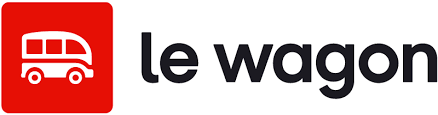

# Orders clustering

The purpose of the exercise is to extract different "typical profiles" of orders and consumers from Greenweez's turnover data. To achieve this, we will apply unsupervised learning algorithms to create order clusters.

## Orders clustering

a) Execute the cell below to load  the data into a `df` variable.

It will select 50k orders randomly (`ORDER BY rand()` in the SQL query).

In [6]:
from google.colab import auth
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# get credentials

df = pd.read_csv('/content/Dataset of all public companies cleaned SQL (1).csv')
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/Dataset of all public companies cleaned SQL (1).csv'

In [ ]:
df.shape

b) Which index do you see?

In [ ]:
# your code here
df.columns

Are there any null values?

In [ ]:
# your code here
df.isnull().sum()

c) Replace null values (if any exist) with 0 using `fillna()`

In [ ]:
# your code here : Replace_value = df.fillna(0)
#Replace_value.head()


In [ ]:
# your code here
#Replace_value.isnull().sum()

d) In a variable called `df_orders`, keep all the turnover columns from the original df. These features will help us cluster orders.

In [ ]:
# your code here
df_orders = df.loc[3:10, ['continent', 'revenues', 'sector']]
df_orders.head()

#df.loc[1:3, ['Name', 'Qualification', 'sector']]

e) Use plotly.express and a box chart to see if the distribution of revenues is different per continent (i.e. feature).

In [ ]:
# your code here
#fig = px.box(df_orders,x='continent', y='revenues')
#fig.show()



In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Exemple : on veut comparer les revenus du secteur "Tech"
continent_A = 'Europe'
continent_B = 'Asia'

df_industrials = df[df['sector'] == 'Industrials']

# Filtrer par secteur
#df_secteur = df[df['sector'] == 'sector']

# Extraire les revenus par continent
revenu_A = df_industrials[df_industrials['continent'] == continent_A]['revenues']
revenu_B = df_industrials[df_industrials['continent'] == continent_B]['revenues']

# Nettoyer les données (juste au cas où)
#revenu_A = pd.to_numeric(revenu_A, errors='coerce').dropna()
#revenu_B = pd.to_numeric(revenu_B, errors='coerce').dropna()

# Vérifier qu'on a assez d'échantillons
if len(revenu_A) < 2 or len(revenu_B) < 2:
    print("⚠️ Pas assez de données pour faire un T-test.")
else:
    # Réaliser le T-test
    t_stat, p_value = ttest_ind(revenu_A, revenu_B, equal_var=False)

    print(f"T-statistic : {t_stat:.4f}")
    print(f"P-value     : {p_value:.4f}")

    # Interprétation
    alpha = 0.05
    if p_value < alpha:
        print("❗ Revenus significativement différents entre les deux continents pour ce secteur.")
    else:
        print("✔️ Aucune différence significative détectée entre les deux continents pour ce secteur.")


In [ ]:
# T-test statistique analyse:
from scipy.stats import ttest_ind

# Exemple : comparer les revenus entre Europe et Asia
secteur_cible = 'Retail	'
continent_A = 'Asia'
continent_B = 'South America'

# Filtrer par secteur
df_secteur = df[df['industry'] == 'industry']

# Extraire les revenus par continent
revenu_A = df_secteur[df_secteur['continent'] == continent_A]['revenues']
revenu_B = df_secteur[df_secteur['continent'] == continent_B]['revenues']

# Nettoyer (au cas où)
#revenu_A = pd.to_numeric(revenu_A, errors='coerce').dropna()
#revenu_B = pd.to_numeric(revenu_B, errors='coerce').dropna()

#HO pas diff entre turnover entreprise euro et South America

# Vérifier qu’on a assez de données
if len(revenu_A) < 2 or len(revenu_B) < 2:
    print("⚠️ Pas assez de données pour faire un T-test.")
else:
    # T-test de Student pour échantillons indépendants
    t_stat, p_value = ttest_ind(revenu_A, revenu_B)

#   print(f"T-statistic : {t_stat:.4f}")
#  print(f"P-value     : {p_value:.4f}")

alpha = 0.05

p_value = ttest_ind(revenu_A, revenu_B).pvalue
print(p_value)

if p_value < alpha:
    print("❗ on rejette H0 donc il ya une difference")
else:
    print("✔️ on accepte ho, Pas de différence significative détectée entre les deux continents.")

In [19]:
# T-test statistique analyse sur le secteur industry mais point de vue pays....
import pandas as pd
from scipy.stats import ttest_ind

# Exemple : on veut comparer les revenus du secteur "Tech"
country_A = 'France'
country_B = 'South Africa'

df_industrials = df[df['sector'] == 'Industrials']

# Filtrer par secteur
#df_secteur = df[df['sector'] == 'sector']

# Extraire les revenus par continent
revenu_A = df_industrials[df_industrials['country'] == country_A]['revenues']
revenu_B = df_industrials[df_industrials['country'] == country_B]['revenues']

# Nettoyer les données (juste au cas où)
#revenu_A = pd.to_numeric(revenu_A, errors='coerce').dropna()
#revenu_B = pd.to_numeric(revenu_B, errors='coerce').dropna()

# Vérifier qu'on a assez d'échantillons
if len(revenu_A) < 2 or len(revenu_B) < 2:
    print("⚠️ Pas assez de données pour faire un T-test.")
else:
    # Réaliser le T-test
    t_stat, p_value = ttest_ind(revenu_A, revenu_B, equal_var=False)

    print(f"T-statistic : {t_stat:.4f}")
    print(f"P-value     : {p_value:.4f}")

    # Interprétation
    alpha = 0.05
    if p_value < alpha:
        print("❗ Revenus significativement différents entre les deux continents pour ce secteur.")
    else:
        print("✔️ Aucune différence significative détectée entre les deux continents pour ce secteur.")


T-statistic : 2.3051
P-value     : 0.0260
❗ Revenus significativement différents entre les deux continents pour ce secteur.


In [ ]:
revenu_A = pd.DataFrame(revenu_A)
revenu_B = pd.DataFrame(revenu_B)

In [ ]:
revenu_A

In [ ]:
import plotly.express as px

revenu_filtré = revenu_A[revenu_A["revenues"] < 10000000000]

fig = px.histogram(revenu_filtré, x="revenues", nbins=20,
                   title="Répartition des CA pour les entreprises Européennes du secteur Industrials")

fig.show()



In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

# Transformation log10 (en ajoutant 1 pour éviter log(0))
revenu_A["log_revenus"] = np.log10(revenu_A["revenues"] + 1)

# Histogramme sur l’échelle log
fig = px.histogram(revenu_A, x="log_revenus", nbins=20,
                   title="Répartition des CA pour les entreprises Européennes du secteur Industrials(échelle logarithmique)")
fig.update_layout(xaxis_title="log10(revenus)", yaxis_title="Nombre d'observations")
fig.show()

In [ ]:
import plotly.express as px

revenu_filtré = revenu_B[revenu_B["revenues"] < 10000000000]

fig = px.histogram(revenu_filtré, x="revenues", nbins=40,
                   title="Répartition des revenus de l'asie",color_discrete_sequence=["yellow"])

fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

# Transformation log10 (en ajoutant 1 pour éviter log(0))
revenu_B["log_revenus"] = np.log10(revenu_B["revenues"] + 1)

# Histogramme sur l’échelle log
fig = px.histogram(revenu_B, x="log_revenus", nbins=20,
                   title="Répartition des CA pour les entreprises Asiatiques du secteur Industrials(échelle logarithmique)",color_discrete_sequence=["yellow"])
fig.update_layout(xaxis_title="log10(revenus)", yaxis_title="Nombre d'observations")
fig.show()


In [ ]:
# prompt de simulation de revenue (test)
def simuler_revenu(continent, secteur, nb_employes, data):
    # Filtrage
    ligne = data[(data['Africa'] == continent) & (data['Industrials'] == secteur)]

    if ligne.empty:
        return "Aucune donnée disponible pour cette combinaison."

    revenu_base = ligne['revenu_moyen'].values[0]
    rentabilite = ligne['rentabilite_moyenne'].values[0]

    # Formule simplifiée de simulation
    revenu_simule = revenu_base + (nb_employes * rentabilite * 1000)  # ou autre facteur

    return round(revenu_simule, 2)
    Print (revenu_simule)


In [ ]:
#code 2 simulation du CA
!pip install streamlit
import streamlit as st
import pandas as pd

# Charger les données
df = pd.read_csv("Dataset of all public companies cleaned SQL (1).csv")
df = df.dropna(subset=['continent', 'sector', 'employees', 'revenues'])
df['employees'] = df['employees'].astype(int)
df['revenues'] = df['revenues'].astype(float)

st.title("💼 Simulateur de Revenu d'Investissement Digital")

continent = st.selectbox("Choisir un continent", df['continent'].unique())
sector = st.selectbox("Choisir un secteur", df[df['continent'] == continent]['sector'].unique())
employees = st.slider("Nombre d'employés", 10, 5000, 100)

# Calcul de la simulation
filtered = df[(df['continent'] == continent) & (df['sector'] == sector)]
avg_rev_per_emp = (filtered['revenues'] / filtered['employees']).mean()
simulated_revenue = round(avg_rev_per_emp * employees, 2)

st.metric("📊 Revenu estimé", f"{simulated_revenue:,.0f} $")

f) Most entries for the column 'turnover_fresh' do not differ from zero, it seems like people are not purchasing these products enough to conduct a meaningful analysis.

Delete the `turnover_fresh` column from `df_orders`.

g) Train a first kmeans algorithm with two a-priori clusters. Remember that distance based models, such as k-means, are greatly effected by scale. Be sure to standardize your data appropriately.


In [ ]:
# your code here
new_df_orders = df_orders.drop('turnover_fresh', axis=1)
new_df_orders.head()


# Apply scaling and convert the resulting NumPy array back to a DataFrame
new_df_orders_scaled = pd.DataFrame(scaler.fit_transform(new_df_orders), columns=new_df_orders.columns)

k_means = KMeans(n_clusters=2, )
k_means.fit(new_df_orders_scaled) # Fit the model on the scaled DataFrame

In [ ]:
new_df_orders_scaled = pd.DataFrame(scaler.fit_transform(new_df_orders), columns=new_df_orders.columns)

k_means = KMeans(n_clusters=2, n_init=10)
k_means.fit(new_df_orders_scaled)
kmeans_pred = k_means.labels_
k_means.cluster_centers_

h) What is inertia for a clustering algorithm? What is inertia for this model?

In [ ]:
# your code here
k_means.inertia_

i) How do we know if 2 clusters a priori was a good choice or not?
Which method could you use?

The elbow method will allow of to check inertias with differing numbers of starting clusters.

j) You will use elbow method.

You will need to loop over different values of  𝑘  (in range 1 to 10) and stores the inertia at each iteration in order to plot its evolution and select the best  𝑘.

Complete code below to do so.

In [ ]:
inertias = []
n_k = range(1, 10)

# for each number of centroids
for k in n_k:

# your code here
    k_means = KMeans(n_clusters=k,n_init=10)
    k_means.fit(new_df_orders_scaled)
    inertias.append(k_means.inertia_)

inertias

k) Use plotly.express to display a line chart of all inertias.

Which number of cluster you recommend and why?

In [ ]:
# your code here
plt.figure(figsize=(15,6))
sns.lineplot(inertias);


<details>
    <summary><i>Solution</i></summary>

It's hard to say for certain, but there could be some elbows between 3 and 5, so let's take 4 clusters as middle ground.
</details>

l) Train a new model with 4 clusters a priori. Use parameter n_init=100 to select best model among 100 tries.

Use `predict()` method to predict in which cluster each row of `df_orders` belong to. We will store results in a `labels` variable.

In [ ]:
# your code here
k_means = KMeans(n_clusters=4, n_init='auto')

labels = k_means.fit_predict(new_df_orders)


m) Use [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html) function of seaborn library to count visualize number of samples per cluster. It is well distributed?

In [ ]:
# your code here

import seaborn as sns
import pandas as pd

# read a tips.csv file from seaborn library
# count plot on the cluster labels
sns.countplot(x=labels)



One bigger cluster and one smaller one... but overall, orders are well distributed.

n) Each KMeans cluster has a center (centroid).

You can get the values of the center for each cluster using the `.cluster_centers_` attribute on your KMeans object.

Create a DataFrame with each cluster's centroid values and the names of the features that the model has been trained on.

In [ ]:
pd.DataFrame(k_means.cluster_centers_, columns=new_df_orders.columns)

In [ ]:
# your code here
k_means.cluster_centers_


o) What conclusions can you draw? What are the different order profiles that emerge?

<details>
    <summary><i>Solution</i></summary>

Remember that the values in each column are the relative coordinates for each centroid across the features. The greater the magnitude of a feature for a cluster, the more important that feature is to that cluster.

In the example above, depending on the random distribution of rows we have pulled with our query, it's likely that you will see 4 types of orders : 1 with mostly groceries, 1 with beauty products, 1 with baby products and 1 with home products.
</details>

p) Add to `df` a new column label containing labels of each sample.

In [ ]:
# your code here
df['label'] = labels
df.head()


q) What does this instruction do? What can you say?

In [ ]:
df[df["promo_rate"] > 0].groupby("label").size()

In [ ]:
 df.groupby("label").size()

In [ ]:
df[df["promo_rate"] > 0].groupby("label").size()/df.groupby("label").size()

Where the promotion rate is greater than zero, we can see that the cluster we have associated with greater grocery turnover uses promotion codes more than others.

In [ ]:
import streamlit as st
import pandas as pd

# Charger les données
df = pd.read_csv("Dataset of all public companies cleaned SQL (1).csv")
df = df.dropna(subset=['continent', 'sector', 'employees', 'revenues'])
df['employees'] = df['employees'].astype(int)
df['revenues'] = df['revenues'].astype(float)

st.title("💼 Simulateur de Revenu d'Investissement Digital")

continent = st.selectbox("Choisir un continent", df['continent'].unique())
sector = st.selectbox("Choisir un secteur", df[df['continent'] == continent]['sector'].unique())
employees = st.slider("Nombre d'employés", 10, 5000, 100)

# Calcul de la simulation
filtered = df[(df['continent'] == continent) & (df['sector'] == sector)]
avg_rev_per_emp = (filtered['revenues'] / filtered['employees']).mean()
simulated_revenue = round(avg_rev_per_emp * employees, 2)

st.metric("📊 Revenu estimé", f"{simulated_revenue:,.0f} $")

In [18]:
filtered

,country,population,continent,company,sector,industry,city,employees,employee type,revenues,revenue type,free cash flow,debt,profits,assets,market cap
0,United States,319259000.0,North America,Walmart,Consumer Defensive,Retail,Bentonville,2300000,actual,5.760130e+11,actual,-1708500000,68477000000,13673000000,244860000000,369234000000
3,United States,319259000.0,North America,The Kroger,Consumer Defensive,Retail,Cincinnati,500000,actual,1.411900e+11,actual,4442000000,20751000000,1655000000,49086000000,36910000000
4,United States,319259000.0,North America,Target,Consumer Defensive,Retail,Minneapolis,450000,actual,1.069780e+11,actual,1168000000,17349000000,6946000000,53811000000,82492700000
12,United States,319259000.0,North America,Costco Wholesale,Consumer Defensive,Retail,Issaquah,288000,actual,2.175380e+11,actual,3377250000,9036000000,5007000000,59268000000,226720000000
20,United States,319259000.0,North America,The Procter & Gamble Company,Consumer Defensive,Consumer Goods,Cincinnati,219931,estimate,8.018700e+10,actual,9285750000,31493000000,14742000000,117208000000,338817000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22254,Cayman Islands,55456.0,North America,Jourdeness Group,Consumer Defensive,Consumer Goods,Grand Cayman,10,estimate,8.597830e+07,actual,14982900,88981500,9201800,265815000,141591000
22255,Cayman Islands,55456.0,North America,San Neng Group,Consumer Defensive,Consumer Goods,Grand Cayman,10,estimate,6.450140e+07,actual,4822710,7803690,6701950,73573600,78353200
22256,Cayman Islands,55456.0,North America,Luo Lih-Fen Holding,Consumer Defensive,Consumer Goods,Grand Cayman,10,estimate,2.898210e+07,actual,-10162900,7632690,2212280,63204000,113433000
22257,Cayman Islands,55456.0,North America,Chlitina Holding,Consumer Defensive,Consumer Goods,Grand Cayman,10,estimate,1.636560e+08,actual,32574300,78099000,42685300,316064000,420619000


In [3]:
from google.colab import auth
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# get credentials

df1 = pd.read_csv('/content/fichier SQL .csv')
df1.head()

,country,population,continent,company,sector,industry,city,employees,revenues,free cash flow,debt,profits,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),net profit per employee
0,United States,319259000.0,North America,Walmart,Consumer Defensive,Retail,Bentonville,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000,2.373731,27.965776,5944.782609
1,United States,319259000.0,North America,Amazon.com,Consumer Cyclical,Internet,Seattle,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000,6.866405,37.465313,21906.762968
2,United States,319259000.0,North America,United Parcel Service,Industrials,Transportation/Trucking/Railroad,Atlanta,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000,12.877252,34.723723,24138.576779
3,United States,319259000.0,North America,The Kroger,Consumer Defensive,Retail,Cincinnati,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000,1.172179,42.274783,3310.000000
4,United States,319259000.0,North America,Target,Consumer Defensive,Retail,Minneapolis,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000,6.492924,32.240620,15435.555556


In [4]:
df_num = df1.select_dtypes(include=['float64', 'int64'])
df_num.head()

,population,employees,revenues,free cash flow,debt,profits,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),net profit per employee
0,319259000.0,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000,2.373731,27.965776,5944.782609
1,319259000.0,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000,6.866405,37.465313,21906.762968
2,319259000.0,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000,12.877252,34.723723,24138.576779
3,319259000.0,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000,1.172179,42.274783,3310.000000
4,319259000.0,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000,6.492924,32.240620,15435.555556


In [5]:
df_drp = df_num.drop(['revenues', 'net profit per employee', 'debt', 'profits'], axis=1)
df_drp.head()

,population,employees,free cash flow,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%)
0,319259000.0,2300000,-1708500000,244860000000,369234000000,2.373731,27.965776
1,319259000.0,1523000,-13441100000,420549000000,514091000000,6.866405,37.465313
2,319259000.0,534000,7236250000,69405000000,172678000000,12.877252,34.723723
3,319259000.0,500000,4442000000,49086000000,36910000000,1.172179,42.274783
4,319259000.0,450000,1168000000,53811000000,82492700000,6.492924,32.240620


In [34]:
Matrice_corr = df_drp.corr()
Matrice_corr

,population,employees,free cash flow,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%)
population,1.000000,0.020014,-0.019354,0.008423,-0.009105,0.006013,-0.002721
employees,0.020014,1.000000,0.127624,0.250631,0.297698,0.001879,-0.002213
free cash flow,-0.019354,0.127624,1.000000,0.020775,0.428921,0.000559,-0.000695
assets,0.008423,0.250631,0.020775,1.000000,0.163832,0.002006,-0.000978
market cap,-0.009105,0.297698,0.428921,0.163832,1.000000,0.001175,-0.001377
profitability_rate (%),0.006013,0.001879,0.000559,0.002006,0.001175,1.000000,-0.000059
debt_to_assets_ratio (%),-0.002721,-0.002213,-0.000695,-0.000978,-0.001377,-0.000059,1.000000


<Axes: >

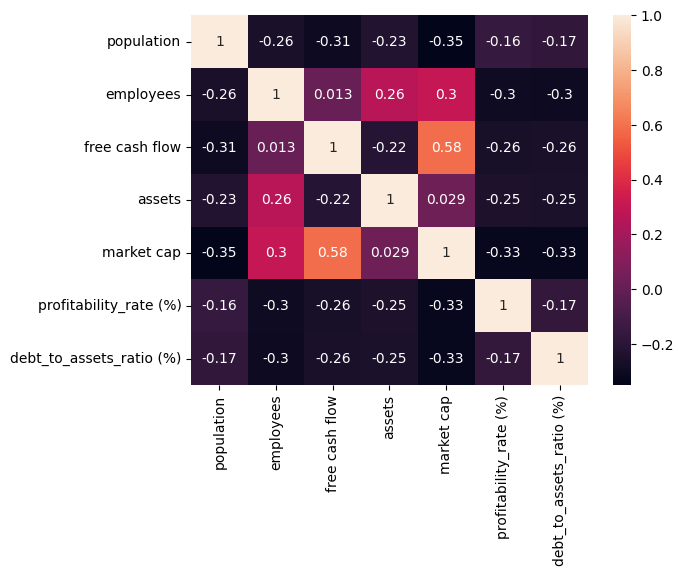

In [40]:
import seaborn as sns

# display correlation matrix
sns.heatmap(Matrice_corr.corr(), annot=True)

In [8]:
df_encoded = pd.get_dummies(df1, columns=['continent'])
df_encoded.head()

,country,population,company,sector,industry,city,employees,revenues,free cash flow,debt,...,market cap,profitability_rate (%),debt_to_assets_ratio (%),net profit per employee,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,United States,319259000.0,Walmart,Consumer Defensive,Retail,Bentonville,2300000,576013000000,-1708500000,68477000000,...,369234000000,2.373731,27.965776,5944.782609,False,False,False,True,False,False
1,United States,319259000.0,Amazon.com,Consumer Cyclical,Internet,Seattle,1523000,485902000000,-13441100000,157560000000,...,514091000000,6.866405,37.465313,21906.762968,False,False,False,True,False,False
2,United States,319259000.0,United Parcel Service,Industrials,Transportation/Trucking/Railroad,Atlanta,534000,100099000000,7236250000,24100000000,...,172678000000,12.877252,34.723723,24138.576779,False,False,False,True,False,False
3,United States,319259000.0,The Kroger,Consumer Defensive,Retail,Cincinnati,500000,141190000000,4442000000,20751000000,...,36910000000,1.172179,42.274783,3310.000000,False,False,False,True,False,False
4,United States,319259000.0,Target,Consumer Defensive,Retail,Minneapolis,450000,106978000000,1168000000,17349000000,...,82492700000,6.492924,32.240620,15435.555556,False,False,False,True,False,False


In [9]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23300 entries, 0 to 23299
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   23300 non-null  object 
 1   population                23300 non-null  float64
 2   company                   23300 non-null  object 
 3   sector                    23300 non-null  object 
 4   industry                  23300 non-null  object 
 5   city                      23295 non-null  object 
 6   employees                 23300 non-null  int64  
 7   revenues                  23300 non-null  int64  
 8   free cash flow            23300 non-null  int64  
 9   debt                      23300 non-null  int64  
 10  profits                   23300 non-null  int64  
 11  assets                    23300 non-null  int64  
 12  market cap                23300 non-null  int64  
 13  profitability_rate (%)    19259 non-null  float64
 14  debt_t

In [10]:
df1_num = df_encoded.select_dtypes(include=['float64', 'int64','bool'])
df1_num.head()

,population,employees,revenues,free cash flow,debt,profits,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),net profit per employee,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,319259000.0,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000,2.373731,27.965776,5944.782609,False,False,False,True,False,False
1,319259000.0,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000,6.866405,37.465313,21906.762968,False,False,False,True,False,False
2,319259000.0,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000,12.877252,34.723723,24138.576779,False,False,False,True,False,False
3,319259000.0,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000,1.172179,42.274783,3310.000000,False,False,False,True,False,False
4,319259000.0,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000,6.492924,32.240620,15435.555556,False,False,False,True,False,False


In [11]:
df1_drp = df1_num.drop(['revenues', 'net profit per employee', 'debt', 'profits'], axis=1)
df1_drp.head()

,population,employees,free cash flow,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,319259000.0,2300000,-1708500000,244860000000,369234000000,2.373731,27.965776,False,False,False,True,False,False
1,319259000.0,1523000,-13441100000,420549000000,514091000000,6.866405,37.465313,False,False,False,True,False,False
2,319259000.0,534000,7236250000,69405000000,172678000000,12.877252,34.723723,False,False,False,True,False,False
3,319259000.0,500000,4442000000,49086000000,36910000000,1.172179,42.274783,False,False,False,True,False,False
4,319259000.0,450000,1168000000,53811000000,82492700000,6.492924,32.240620,False,False,False,True,False,False


In [12]:
Matrice_corr1 = df1_drp.corr()
Matrice_corr1

,population,employees,free cash flow,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
population,1.000000,0.020014,-0.019354,0.008423,-0.009105,0.006013,-0.002721,-0.035328,0.406315,-0.274651,-0.146788,-0.151867,-0.044711
employees,0.020014,1.000000,0.127624,0.250631,0.297698,0.001879,-0.002213,0.008024,-0.024570,0.042108,0.004838,-0.030394,0.007482
free cash flow,-0.019354,0.127624,1.000000,0.020775,0.428921,0.000559,-0.000695,0.002532,-0.050041,0.027783,0.035981,-0.008017,0.004304
assets,0.008423,0.250631,0.020775,1.000000,0.163832,0.002006,-0.000978,-0.000586,-0.006449,0.017614,-0.000533,-0.013575,-0.000353
market cap,-0.009105,0.297698,0.428921,0.163832,1.000000,0.001175,-0.001377,0.000082,-0.027818,0.000106,0.039760,-0.016865,-0.003253
profitability_rate (%),0.006013,0.001879,0.000559,0.002006,0.001175,1.000000,-0.000059,0.000559,0.010614,0.004057,0.002068,-0.043155,0.001286
debt_to_assets_ratio (%),-0.002721,-0.002213,-0.000695,-0.000978,-0.001377,-0.000059,1.000000,-0.000625,-0.009981,-0.004715,0.016969,-0.002335,-0.001246
continent_Africa,-0.035328,0.008024,0.002532,-0.000586,0.000082,0.000559,-0.000625,1.000000,-0.056568,-0.023610,-0.033952,-0.012076,-0.006053
continent_Asia,0.406315,-0.024570,-0.050041,-0.006449,-0.027818,0.010614,-0.009981,-0.056568,1.000000,-0.436963,-0.628365,-0.223488,-0.112026
continent_Europe,-0.274651,0.042108,0.027783,0.017614,0.000106,0.004057,-0.004715,-0.023610,-0.436963,1.000000,-0.262269,-0.093280,-0.046758


<Axes: >

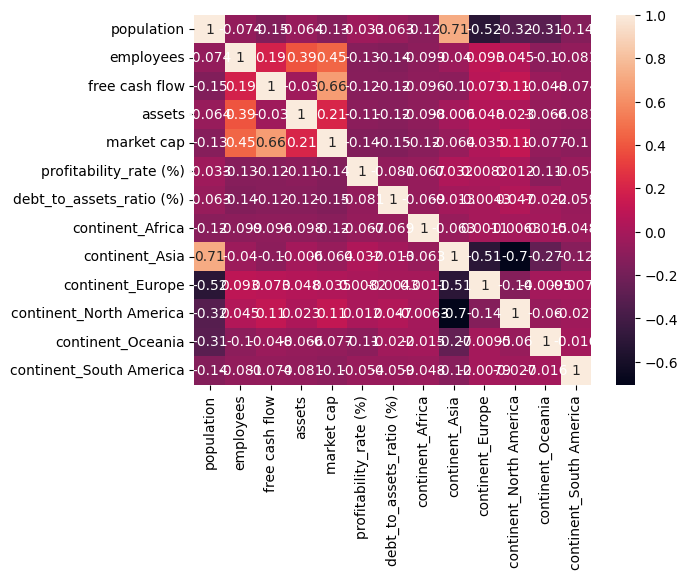

In [13]:
# display correlation matrix
sns.heatmap(Matrice_corr1.corr(), annot=True)

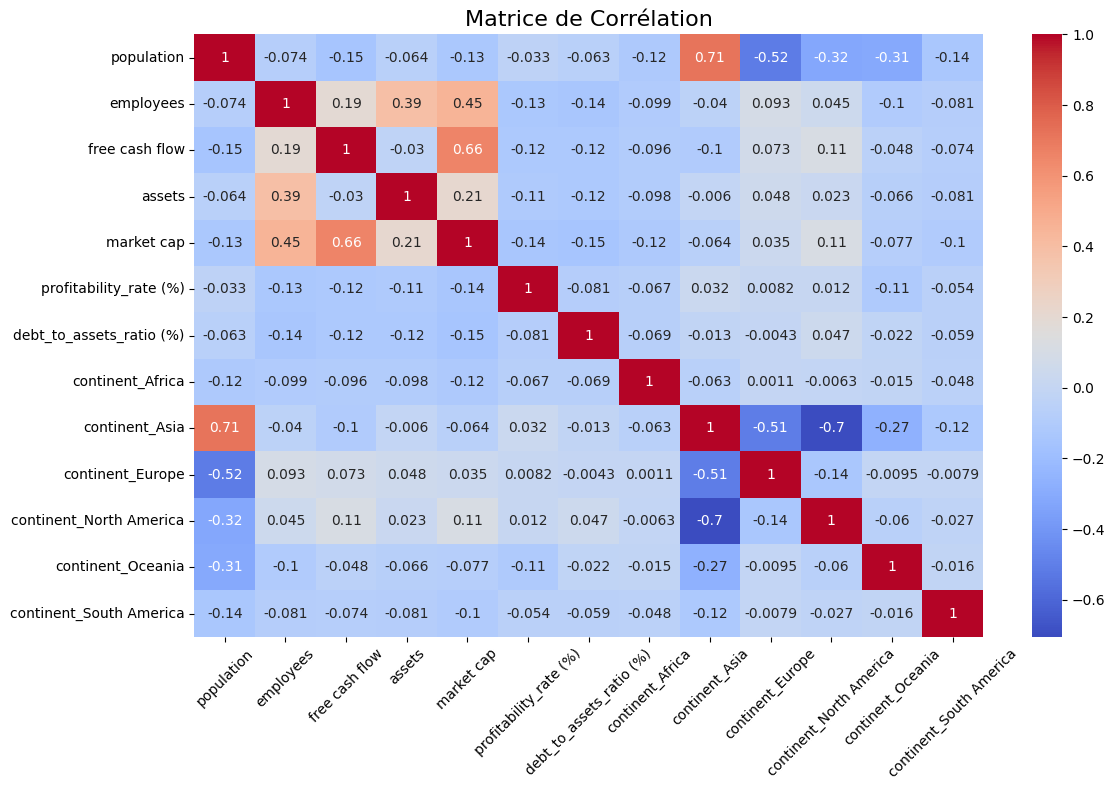

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))  # 🔁 Change les dimensions ici (en pouces)
sns.heatmap(Matrice_corr1.corr(), annot=True, cmap="coolwarm")

plt.title("Matrice de Corrélation", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [15]:
# get credentials

da = pd.read_csv('/content/fichier SQL .csv')
da.head()

,country,population,continent,company,sector,industry,city,employees,revenues,free cash flow,debt,profits,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),net profit per employee
0,United States,319259000.0,North America,Walmart,Consumer Defensive,Retail,Bentonville,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000,2.373731,27.965776,5944.782609
1,United States,319259000.0,North America,Amazon.com,Consumer Cyclical,Internet,Seattle,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000,6.866405,37.465313,21906.762968
2,United States,319259000.0,North America,United Parcel Service,Industrials,Transportation/Trucking/Railroad,Atlanta,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000,12.877252,34.723723,24138.576779
3,United States,319259000.0,North America,The Kroger,Consumer Defensive,Retail,Cincinnati,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000,1.172179,42.274783,3310.000000
4,United States,319259000.0,North America,Target,Consumer Defensive,Retail,Minneapolis,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000,6.492924,32.240620,15435.555556


In [16]:
da_num = da.select_dtypes(include=['float64', 'int64'])
da_num.head()

,population,employees,revenues,free cash flow,debt,profits,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),net profit per employee
0,319259000.0,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000,2.373731,27.965776,5944.782609
1,319259000.0,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000,6.866405,37.465313,21906.762968
2,319259000.0,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000,12.877252,34.723723,24138.576779
3,319259000.0,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000,1.172179,42.274783,3310.000000
4,319259000.0,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000,6.492924,32.240620,15435.555556


In [17]:
da_drp = da_num.drop(['profitability_rate (%)', 'net profit per employee', 'debt_to_assets_ratio (%)'], axis=1)
da_drp.head()

,population,employees,revenues,free cash flow,debt,profits,assets,market cap
0,319259000.0,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000
1,319259000.0,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000
2,319259000.0,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000
3,319259000.0,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000
4,319259000.0,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000


In [18]:
Matrice_corra = da_drp.corr()
Matrice_corra

,population,employees,revenues,free cash flow,debt,profits,assets,market cap
population,1.000000,0.020014,0.002757,-0.019354,0.001561,-0.001957,0.008423,-0.009105
employees,0.020014,1.000000,0.695114,0.127624,0.180344,0.202089,0.250631,0.297698
revenues,0.002757,0.695114,1.000000,0.340902,0.204904,0.304945,0.255098,0.486515
free cash flow,-0.019354,0.127624,0.340902,1.000000,0.017694,0.222693,0.020775,0.428921
debt,0.001561,0.180344,0.204904,0.017694,1.000000,0.158265,0.574595,0.119832
profits,-0.001957,0.202089,0.304945,0.222693,0.158265,1.000000,0.696363,0.327623
assets,0.008423,0.250631,0.255098,0.020775,0.574595,0.696363,1.000000,0.163832
market cap,-0.009105,0.297698,0.486515,0.428921,0.119832,0.327623,0.163832,1.000000


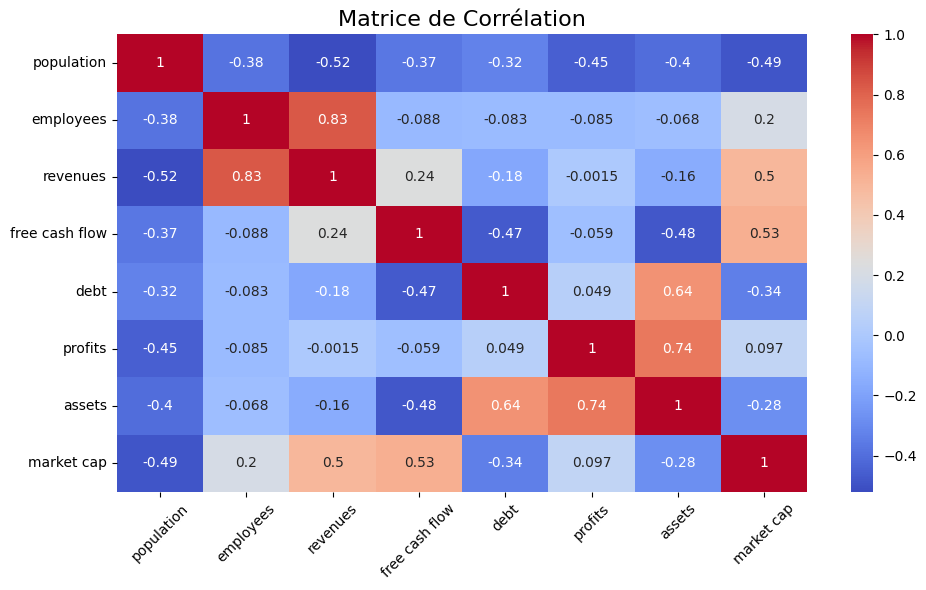

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))  # 🔁 Change les dimensions ici (en pouces)
sns.heatmap(Matrice_corra.corr(), annot=True, cmap="coolwarm")

plt.title("Matrice de Corrélation", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
dp = pd.read_csv('/content/fichier SQL .csv')
dp.head()

,country,population,continent,company,sector,industry,city,employees,revenues,free cash flow,debt,profits,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),net profit per employee
0,United States,319259000.0,North America,Walmart,Consumer Defensive,Retail,Bentonville,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000,2.373731,27.965776,5944.782609
1,United States,319259000.0,North America,Amazon.com,Consumer Cyclical,Internet,Seattle,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000,6.866405,37.465313,21906.762968
2,United States,319259000.0,North America,United Parcel Service,Industrials,Transportation/Trucking/Railroad,Atlanta,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000,12.877252,34.723723,24138.576779
3,United States,319259000.0,North America,The Kroger,Consumer Defensive,Retail,Cincinnati,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000,1.172179,42.274783,3310.000000
4,United States,319259000.0,North America,Target,Consumer Defensive,Retail,Minneapolis,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000,6.492924,32.240620,15435.555556


In [21]:
dp.describe()


,population,employees,revenues,free cash flow,debt,profits,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),net profit per employee
count,2.330000e+04,2.330000e+04,2.330000e+04,2.330000e+04,2.330000e+04,2.330000e+04,2.330000e+04,2.330000e+04,1.925900e+04,2.090700e+04,1.925900e+04
mean,3.626147e+08,5.779900e+03,2.207629e+09,9.825084e+07,2.269728e+09,2.205365e+08,1.033956e+10,3.865232e+09,-2.010367e+03,inf,5.720940e+05
std,4.896895e+08,3.114626e+04,1.258142e+10,1.802293e+09,3.360732e+10,3.521231e+09,1.278768e+11,3.327867e+10,2.169936e+05,NaN,1.266068e+07
min,3.000100e+04,1.000000e+00,1.000000e+00,-1.423910e+11,0.000000e+00,-1.185550e+10,0.000000e+00,0.000000e+00,-2.946995e+07,2.463218e-04,-1.447107e+08
25%,3.554042e+07,5.600000e+01,2.444182e+07,-4.412900e+06,2.571740e+06,0.000000e+00,4.742088e+07,3.536928e+07,6.768724e-03,7.134207e+00,1.090716e+01
50%,1.270800e+08,4.620000e+02,1.483240e+08,0.000000e+00,3.518240e+07,4.301355e+06,3.002465e+08,2.176075e+08,4.961867e+00,2.218443e+01,1.307888e+04
75%,3.192590e+08,2.363000e+03,7.224922e+08,1.208562e+07,3.166732e+08,4.649995e+07,1.480490e+09,1.072560e+09,1.271847e+01,4.167456e+01,5.654480e+04
max,1.367110e+09,2.300000e+06,5.760130e+11,8.334460e+10,4.209270e+12,4.700080e+11,1.090380e+13,2.480260e+12,2.899179e+06,inf,1.283325e+09


In [22]:
dp_encoded = pd.get_dummies(dp, columns=['sector'])
dp_encoded.head()

,country,population,continent,company,industry,city,employees,revenues,free cash flow,debt,...,sector_Financial,sector_Financial Services,sector_Healthcare,sector_Industrial Goods,sector_Industrials,sector_Real Estate,sector_Services,sector_Technology,sector_Utilities,sector_unidentified
0,United States,319259000.0,North America,Walmart,Retail,Bentonville,2300000,576013000000,-1708500000,68477000000,...,False,False,False,False,False,False,False,False,False,False
1,United States,319259000.0,North America,Amazon.com,Internet,Seattle,1523000,485902000000,-13441100000,157560000000,...,False,False,False,False,False,False,False,False,False,False
2,United States,319259000.0,North America,United Parcel Service,Transportation/Trucking/Railroad,Atlanta,534000,100099000000,7236250000,24100000000,...,False,False,False,False,True,False,False,False,False,False
3,United States,319259000.0,North America,The Kroger,Retail,Cincinnati,500000,141190000000,4442000000,20751000000,...,False,False,False,False,False,False,False,False,False,False
4,United States,319259000.0,North America,Target,Retail,Minneapolis,450000,106978000000,1168000000,17349000000,...,False,False,False,False,False,False,False,False,False,False


In [23]:
dp1_num = dp_encoded.select_dtypes(include=['float64', 'int64','bool'])
dp1_num.head()

,population,employees,revenues,free cash flow,debt,profits,assets,market cap,profitability_rate (%),debt_to_assets_ratio (%),...,sector_Financial,sector_Financial Services,sector_Healthcare,sector_Industrial Goods,sector_Industrials,sector_Real Estate,sector_Services,sector_Technology,sector_Utilities,sector_unidentified
0,319259000.0,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000,2.373731,27.965776,...,False,False,False,False,False,False,False,False,False,False
1,319259000.0,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000,6.866405,37.465313,...,False,False,False,False,False,False,False,False,False,False
2,319259000.0,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000,12.877252,34.723723,...,False,False,False,False,True,False,False,False,False,False
3,319259000.0,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000,1.172179,42.274783,...,False,False,False,False,False,False,False,False,False,False
4,319259000.0,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000,6.492924,32.240620,...,False,False,False,False,False,False,False,False,False,False


In [27]:
dp_drp = dp1_num.drop(['profitability_rate (%)', 'net profit per employee', 'debt_to_assets_ratio (%)'], axis=1)
dp_drp.head()

,population,employees,revenues,free cash flow,debt,profits,assets,market cap,sector_Basic Materials,sector_Communication Services,...,sector_Financial,sector_Financial Services,sector_Healthcare,sector_Industrial Goods,sector_Industrials,sector_Real Estate,sector_Services,sector_Technology,sector_Utilities,sector_unidentified
0,319259000.0,2300000,576013000000,-1708500000,68477000000,13673000000,244860000000,369234000000,False,False,...,False,False,False,False,False,False,False,False,False,False
1,319259000.0,1523000,485902000000,-13441100000,157560000000,33364000000,420549000000,514091000000,False,False,...,False,False,False,False,False,False,False,False,False,False
2,319259000.0,534000,100099000000,7236250000,24100000000,12890000000,69405000000,172678000000,False,False,...,False,False,False,False,True,False,False,False,False,False
3,319259000.0,500000,141190000000,4442000000,20751000000,1655000000,49086000000,36910000000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,319259000.0,450000,106978000000,1168000000,17349000000,6946000000,53811000000,82492700000,False,False,...,False,False,False,False,False,False,False,False,False,False


In [25]:
Matrice_corrp = dp_drp.corr()
Matrice_corrp

,population,employees,revenues,free cash flow,debt,profits,assets,market cap,sector_Basic Materials,sector_Communication Services,...,sector_Financial,sector_Financial Services,sector_Healthcare,sector_Industrial Goods,sector_Industrials,sector_Real Estate,sector_Services,sector_Technology,sector_Utilities,sector_unidentified
population,1.000000,0.020014,0.002757,-0.019354,0.001561,-0.001957,0.008423,-0.009105,-0.001975,0.000758,...,-0.001588,-0.060210,0.006167,0.008289,0.042867,-0.026035,0.011374,0.015419,0.001608,-0.022136
employees,0.020014,1.000000,0.695114,0.127624,0.180344,0.202089,0.250631,0.297698,-0.038618,0.000773,...,-0.003218,0.004713,-0.022242,-0.002108,0.015885,-0.026050,-0.002269,-0.001159,-0.002071,-0.006827
revenues,0.002757,0.695114,1.000000,0.340902,0.204904,0.304945,0.255098,0.486515,-0.021715,0.007856,...,-0.003076,0.008557,-0.008353,-0.002140,-0.010805,-0.022720,-0.002601,-0.017371,0.026684,-0.006341
free cash flow,-0.019354,0.127624,0.340902,1.000000,0.017694,0.222693,0.020775,0.428921,-0.009625,0.024732,...,-0.001059,-0.002130,0.005228,-0.000469,-0.009733,-0.010577,-0.000860,0.004855,-0.009141,-0.001997
debt,0.001561,0.180344,0.204904,0.017694,1.000000,0.158265,0.574595,0.119832,-0.019257,-0.001928,...,-0.001294,0.095179,-0.015724,-0.000880,-0.017680,-0.001866,-0.001067,-0.019378,0.010566,-0.002565
profits,-0.001957,0.202089,0.304945,0.222693,0.158265,1.000000,0.696363,0.327623,-0.007911,0.009284,...,-0.000994,0.030925,-0.007429,-0.000733,-0.015676,0.016818,-0.000977,-0.006158,0.000779,-0.002423
assets,0.008423,0.250631,0.255098,0.020775,0.574595,0.696363,1.000000,0.163832,-0.024194,-0.007361,...,-0.001550,0.133880,-0.020663,-0.001034,-0.026239,0.006618,-0.001288,-0.024145,0.002876,-0.003114
market cap,-0.009105,0.297698,0.486515,0.428921,0.119832,0.327623,0.163832,1.000000,-0.020336,0.009890,...,-0.002169,0.023710,-0.001880,-0.001404,-0.020696,-0.001218,-0.001833,0.009385,0.011284,-0.004102
sector_Basic Materials,-0.001975,-0.038618,-0.021715,-0.009625,-0.019257,-0.007911,-0.024194,-0.020336,1.000000,-0.082391,...,-0.007194,-0.135334,-0.120938,-0.004795,-0.173652,-0.090294,-0.005873,-0.139067,-0.052452,-0.014791
sector_Communication Services,0.000758,0.000773,0.007856,0.024732,-0.001928,0.009284,-0.007361,0.009890,-0.082391,1.000000,...,-0.004426,-0.083255,-0.074399,-0.002950,-0.106827,-0.055547,-0.003613,-0.085551,-0.032268,-0.009099


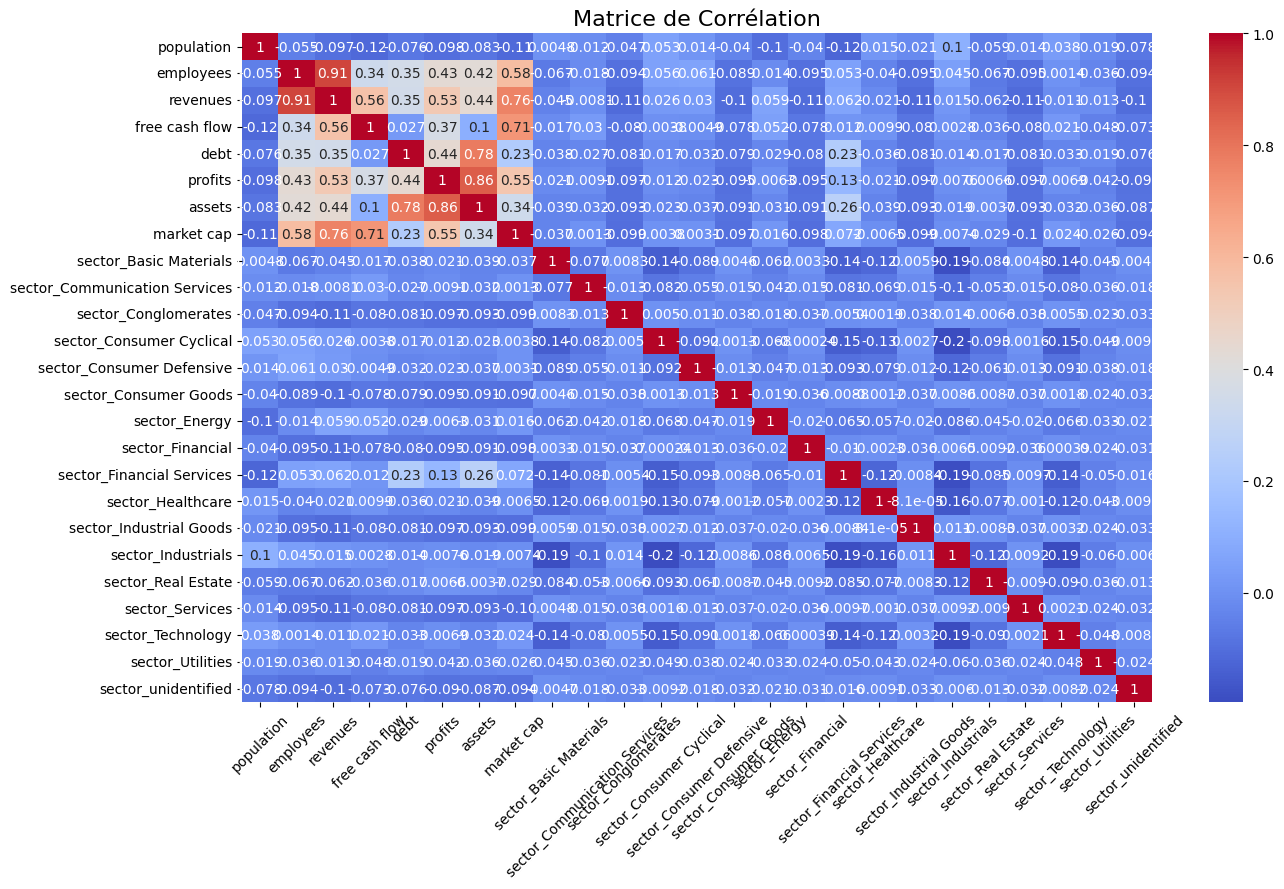

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 9))  # 🔁 Change les dimensions ici (en pouces)
sns.heatmap(Matrice_corrp.corr(), annot=True, cmap="coolwarm")

plt.title("Matrice de Corrélation", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()